# ТК 1-2. Парная регрессия на гиперспектре кукурузы
1. Линейная модель: формулы + градиентный спуск.
2. Парабола (нелинейная аппроксимация): формулы + градиентный спуск.
Аргумент масштабируем: `x = wavelength * 0.001` (иначе спуск расходится).

Точек: 273


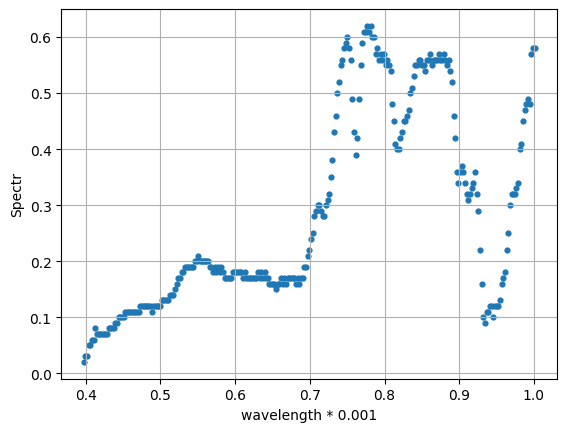

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка; в csv разделитель ';' и десятичная запятая
df = pd.read_csv("Гиперспектр кукурузы.csv", sep=";", decimal=",")
x = df["wavelength"].to_numpy(dtype=float) * 0.001
Y = df["Spectr"].to_numpy(dtype=float)
print("Точек:", len(x))

plt.figure()
plt.scatter(x, Y, s=12)
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.grid(True)
plt.show()

## 1. Прямая по формулам (МНК)

Формулы: $a_1 = \overline{(x-\bar x)(Y-\bar Y)} / \overline{(x-\bar x)^2}$, $a_0 = \bar Y - a_1 \bar x$

Y^ = -0.1834 + 0.6682 * x
MSE = 0.017684


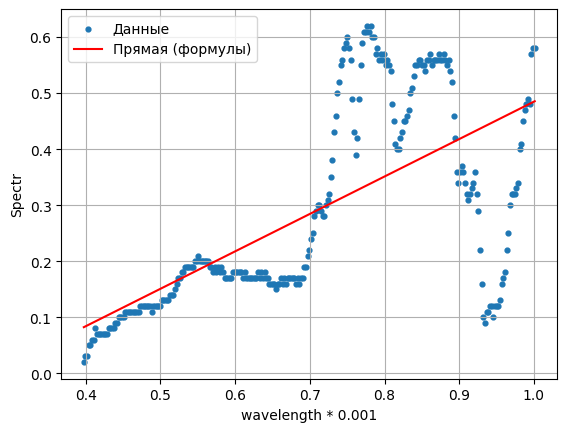

In [2]:
a1 = ((x - x.mean()) * (Y - Y.mean())).mean() / (((x - x.mean()) ** 2).mean())
a0 = Y.mean() - a1 * x.mean()
print(f"Y^ = {a0:.4f} + {a1:.4f} * x")

Y_lin = a0 + a1 * x
mse_lin = ((Y - Y_lin) ** 2).mean()
print(f"MSE = {mse_lin:.6f}")

xs = np.linspace(x.min(), x.max(), 200)
plt.figure()
plt.scatter(x, Y, s=12, label="Данные")
plt.plot(xs, a0 + a1 * xs, 'r', label="Прямая (формулы)")
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.legend()
plt.grid(True)
plt.show()

## 2. Прямая градиентным спуском

Y^ = -0.1834 + 0.6682 * x
MSE = 0.017684 (формулы давали 0.017684 — сошлось)


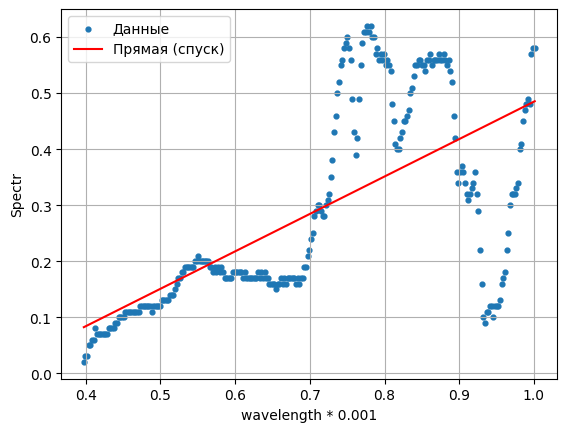

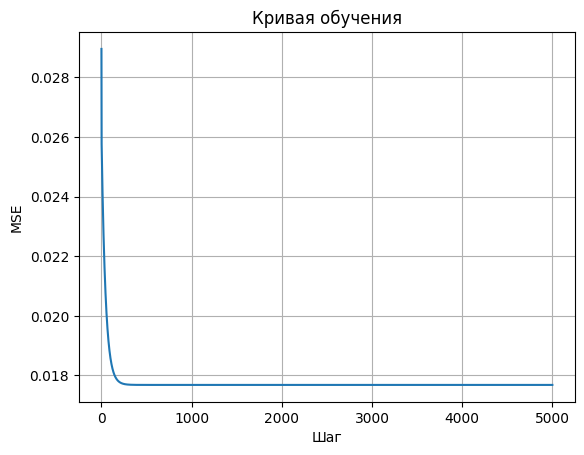

In [3]:
class SimpleRegression:
    def __init__(self):
        self.a0 = 0.0
        self.a1 = 0.0
    def predict(self, x):
        return self.a0 + self.a1 * x
    def MSE(self, x, Y):
        return ((self.predict(x) - Y) ** 2).mean()
    def fit(self, x, Y, alpha=0.001, max_steps=5000):
        errors = []
        for _ in range(max_steps):
            r = Y - self.predict(x)
            self.a0 -= alpha * (-2 * np.sum(r))
            self.a1 -= alpha * (-2 * np.sum(r * x))
            errors.append(self.MSE(x, Y))
        return errors

regr = SimpleRegression()
errors = regr.fit(x, Y)
print(f"Y^ = {regr.a0:.4f} + {regr.a1:.4f} * x")
print(f"MSE = {regr.MSE(x, Y):.6f} (формулы давали {mse_lin:.6f} — сошлось)")

plt.figure()
plt.scatter(x, Y, s=12, label="Данные")
plt.plot(xs, regr.predict(xs), 'r', label="Прямая (спуск)")
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(errors)
plt.xlabel("Шаг")
plt.ylabel("MSE")
plt.title("Кривая обучения")
plt.grid(True)
plt.show()

## 3. Парабола по формулам

Берем параболу $Y = a_0 + a_1 x + a_2 x^2$, коэффициенты — МНК через нормальные уравнения (`np.linalg.lstsq`).

Y^ = -1.0174 + 3.2129*x + -1.8197*x^2
MSE = 0.015202 (у прямой было 0.017684 — парабола лучше)


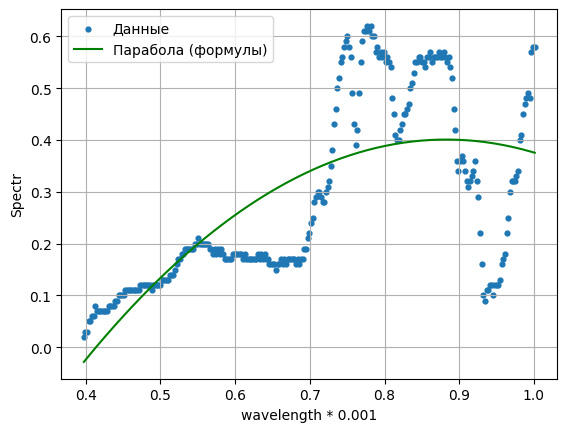

In [4]:
Xq = np.vstack([np.ones_like(x), x, x ** 2]).T
coef, *_ = np.linalg.lstsq(Xq, Y, rcond=None)
b0, b1, b2 = coef
print(f"Y^ = {b0:.4f} + {b1:.4f}*x + {b2:.4f}*x^2")

mse_par = ((Y - Xq @ coef) ** 2).mean()
print(f"MSE = {mse_par:.6f} (у прямой было {mse_lin:.6f} — парабола лучше)")

plt.figure()
plt.scatter(x, Y, s=12, label="Данные")
plt.plot(xs, np.vstack([np.ones_like(xs), xs, xs ** 2]).T @ coef, 'g', label="Парабола (формулы)")
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.legend()
plt.grid(True)
plt.show()

## 4. Парабола градиентным спуском

Y^ = -0.7417 + 2.3809*x + -1.2303*x^2
MSE = 0.015465 (формулы давали 0.015202)


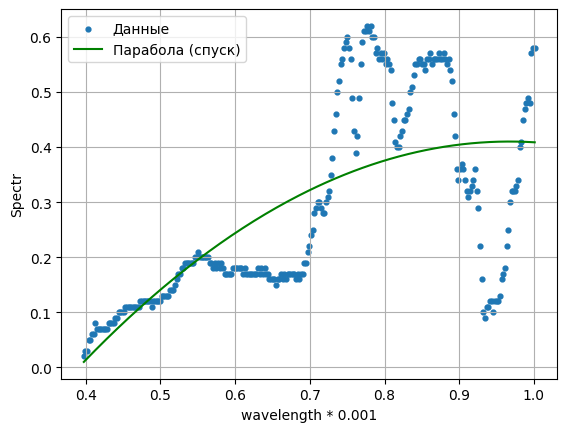

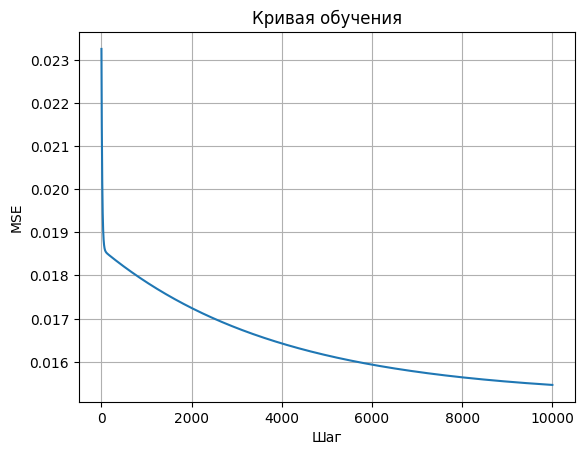

In [5]:
class ParabolicRegression:
    def __init__(self):
        self.a0, self.a1, self.a2 = 0.0, 0.0, 0.0
    def predict(self, x):
        return self.a0 + self.a1 * x + self.a2 * x ** 2
    def MSE(self, x, Y):
        return ((self.predict(x) - Y) ** 2).mean()
    def fit(self, x, Y, alpha=0.001, max_steps=10000):
        errors = []
        for _ in range(max_steps):
            r = Y - self.predict(x)
            self.a0 -= alpha * (-2 * np.sum(r))
            self.a1 -= alpha * (-2 * np.sum(r * x))
            self.a2 -= alpha * (-2 * np.sum(r * x ** 2))
            errors.append(self.MSE(x, Y))
        return errors

preg = ParabolicRegression()
errors_p = preg.fit(x, Y)
print(f"Y^ = {preg.a0:.4f} + {preg.a1:.4f}*x + {preg.a2:.4f}*x^2")
print(f"MSE = {preg.MSE(x, Y):.6f} (формулы давали {mse_par:.6f})")

plt.figure()
plt.scatter(x, Y, s=12, label="Данные")
plt.plot(xs, preg.predict(xs), 'g', label="Парабола (спуск)")
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(errors_p)
plt.xlabel("Шаг")
plt.ylabel("MSE")
plt.title("Кривая обучения")
plt.grid(True)
plt.show()

## 5. Сравнение

Прямая (формулы):   MSE = 0.017684
Прямая (спуск):     MSE = 0.017684
Парабола (формулы): MSE = 0.015202
Парабола (спуск):   MSE = 0.015465


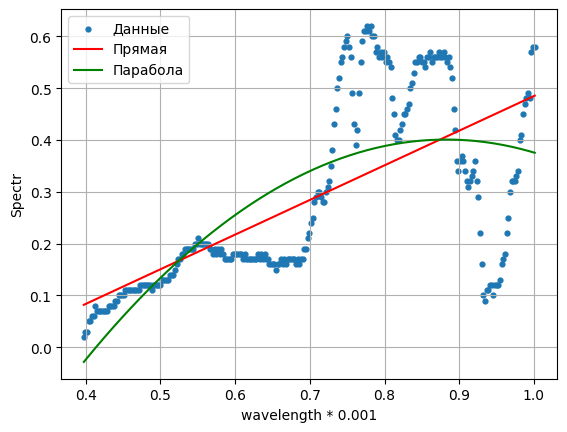

In [6]:
print(f"Прямая (формулы):   MSE = {mse_lin:.6f}")
print(f"Прямая (спуск):     MSE = {regr.MSE(x, Y):.6f}")
print(f"Парабола (формулы): MSE = {mse_par:.6f}")
print(f"Парабола (спуск):   MSE = {preg.MSE(x, Y):.6f}")

plt.figure()
plt.scatter(x, Y, s=12, label="Данные")
plt.plot(xs, a0 + a1 * xs, 'r', label="Прямая")
plt.plot(xs, np.vstack([np.ones_like(xs), xs, xs ** 2]).T @ coef, 'g', label="Парабола")
plt.xlabel("wavelength * 0.001")
plt.ylabel("Spectr")
plt.legend()
plt.grid(True)
plt.show()

**Выводы:** без масштабирования `x*0.001` спуск расходится; спуск сошелся к формулам; парабола точнее прямой (меньше MSE), зависимость нелинейная; кривые обучения падают — шаг подобран верно.